# Multinomial logistic regression and evaluation: a companion notebook

**Human Language Technologies 2026-27, Lecture 07.** Claudio Gallicchio, University of Pisa.

This notebook lets you run the examples of the lecture and check the exercises of the exercise sheet. It follows Chapter 4 of Jurafsky and Martin, *Speech and Language Processing* (3rd edition draft, August 2026), sections 4.7 to 4.16.

1. The softmax
2. A three-way classifier by hand: scores, loss, gradient
3. A three-class sentiment dataset
4. Multinomial logistic regression from scratch
5. Evaluation: confusion matrix, precision, recall, F-measure
6. Test sets and cross-validation
7. The paired bootstrap test
8. Overfitting and regularization
9. Interpreting the model
10. What to do next

How to use it: run the cells from top to bottom (Jupyter, VS Code or Google Colab). Only the Python standard library, `numpy` and `matplotlib` are needed, and no internet connection. Section 4 uses the matrix form of the book, W of shape K × f, so `numpy` is used from the start.

## 1. The softmax

The softmax turns a vector of K scores, the logits, into K probabilities that sum to 1 (Eq. 4.33). First the example of the book, then two properties: adding a constant to all the scores does not change the result, and multiplying them by a constant larger than 1 sharpens the distribution (exercise 1 of the exercise sheet). With two classes the softmax is the sigmoid of the difference of the two scores (exercise 2).

In [1]:
import math
import numpy as np
np.set_printoptions(precision=4, suppress=True)

def softmax(z):
    z = np.asarray(z, dtype=float)
    e = np.exp(z - z.max())          # subtracting the maximum does not change the result and avoids overflow
    return e / e.sum()

z = np.array([0.6, 1.1, -1.5, 1.2, 3.2, -1.1])
print("z          ", z)
print("exp(z)     ", np.exp(z), " sum", round(np.exp(z).sum(), 2))
print("softmax(z) ", softmax(z), " sum", softmax(z).sum())
print()
z1 = np.array([2.0, 1.0, 0.0])
print("exercise 1:", softmax(z1), " z + 3:", softmax(z1 + 3), " 2z:", softmax(2 * z1))
sigmoid = lambda x: 1 / (1 + math.exp(-x))
print("exercise 2: softmax([1.5, 0.3])[0] =", softmax([1.5, 0.3])[0].round(4), " sigmoid(1.5 - 0.3) =", round(sigmoid(1.2), 4))

z           [ 0.6  1.1 -1.5  1.2  3.2 -1.1]
exp(z)      [ 1.8221  3.0042  0.2231  3.3201 24.5325  0.3329]  sum 33.23
softmax(z)  [0.0548 0.0904 0.0067 0.0999 0.7382 0.01  ]  sum 0.9999999999999999

exercise 1: [0.6652 0.2447 0.09  ]  z + 3: [0.6652 0.2447 0.09  ]  2z: [0.8668 0.1173 0.0159]
exercise 2: softmax([1.5, 0.3])[0] = 0.7685  sigmoid(1.5 - 0.3) = 0.7685


The loss of multinomial logistic regression is minus the log probability of the correct class (Eq. 4.39): on the example of the book, 0.30 if the correct class is the fifth and 2.4 if it is the second, as in the lecture.

In [2]:
def ce_loss(y_hat, c):
    """cross-entropy loss of the probability vector y_hat when the correct class is c (0-based)"""
    return -math.log(y_hat[c])

p = softmax(z)
for c in (4, 1):
    print(f"correct class {c + 1}: probability {p[c]:.2f}, loss {ce_loss(p, c):.2f}")

correct class 5: probability 0.74, loss 0.30
correct class 2: probability 0.09, loss 2.40


## 2. A three-way classifier by hand: scores, loss, gradient

Exercises 3 and 4 of the exercise sheet: a classifier for positive, negative and neutral reviews with two features, the counts of positive and of negative lexicon words. The weight matrix W has one row per class, a prototype of the class (Eq. 4.36); the scores are z = Wx + b. The gradient of the loss with respect to W is the outer product (ŷ - y) x<sup>T</sup> (Eq. 4.41), and with respect to b it is ŷ - y. We check the gradient numerically, by perturbing each weight a little.

In [3]:
W = np.array([[2.0, -1.5], [-1.0, 2.5], [0.2, 0.3]])
b = np.array([0.5, 0.0, 1.0])
x = np.array([3.0, 2.0])
CLASSES = ["positive", "negative", "neutral"]

z = W @ x + b
y_hat = softmax(z)
print("z =", z, " y_hat =", y_hat, " class:", CLASSES[int(y_hat.argmax())])
print("loss if positive:", round(ce_loss(y_hat, 0), 3), " loss if neutral:", round(ce_loss(y_hat, 2), 3))

def gradient(W, b, x, c):
    y = np.zeros(len(b)); y[c] = 1
    err = softmax(W @ x + b) - y
    return np.outer(err, x), err

gW, gb = gradient(W, b, x, 2)
print("\ngradient of W (correct class neutral):\n", gW.round(3), "\ngradient of b:", gb.round(3))

def numerical_gradient(W, b, x, c, eps=1e-6):
    loss = lambda W, b: ce_loss(softmax(W @ x + b), c)
    nW = np.zeros_like(W); nb = np.zeros_like(b)
    for k in range(W.shape[0]):
        for i in range(W.shape[1]):
            Wp = W.copy(); Wp[k, i] += eps; Wm = W.copy(); Wm[k, i] -= eps
            nW[k, i] = (loss(Wp, b) - loss(Wm, b)) / (2 * eps)
        bp = b.copy(); bp[k] += eps; bm = b.copy(); bm[k] -= eps
        nb[k] = (loss(W, bp) - loss(W, bm)) / (2 * eps)
    return nW, nb
nW, nb = numerical_gradient(W, b, x, 2)
print("largest difference from the numerical gradient:", max(abs(nW - gW).max(), abs(nb - gb).max()))

W1, b1 = W - 0.1 * gW, b - 0.1 * gb
p1 = softmax(W1 @ x + b1)
print("\nafter one step with eta = 0.1: W =\n", W1.round(3), "\nb =", b1.round(3), "\ny_hat =", p1, " loss if neutral:", round(ce_loss(p1, 2), 3))

z = [3.5 2.  2.2]  y_hat = [0.6686 0.1492 0.1822]  class: positive
loss if positive: 0.403  loss if neutral: 1.703

gradient of W (correct class neutral):
 [[ 2.006  1.337]
 [ 0.448  0.298]
 [-2.453 -1.636]] 
gradient of b: [ 0.669  0.149 -0.818]
largest difference from the numerical gradient: 1.3803957976676884e-10

after one step with eta = 0.1: W =
 [[ 1.799 -1.634]
 [-1.045  2.47 ]
 [ 0.445  0.464]] 
b = [ 0.433 -0.015  1.082] 
y_hat = [0.2743 0.1267 0.599 ]  loss if neutral: 0.512


The row of the correct class moved toward x and the two other rows away from it: after one step the review is classified as neutral.

## 3. A three-class sentiment dataset

To train and evaluate a classifier we need many labeled reviews. As in the notebook of the previous lecture, we generate them from templates: positive and negative reviews praise or criticize a few aspects of a film, sometimes with a negation; neutral reviews state facts about the film, with at most one opinion clause. Five percent of the labels are flipped, as real annotations are never perfectly consistent. The classes are not balanced: neutral reviews are fewer, like the urgent emails of the book. A fixed split: 1800 training reviews and 600 test reviews.

In [4]:
import random
from collections import Counter

POS_WORDS = ["great", "nice", "enjoyable", "wonderful", "brilliant", "moving", "fun", "superb"]
NEG_WORDS = ["boring", "awful", "hokey", "second-rate", "dull", "predictable", "weak", "terrible"]
ASPECTS = ["the acting", "the plot", "the music", "the script", "the cast", "the ending", "the dialogue", "the photography"]
FACTS = ["the film lasts two hours", "it was shot in rome and in paris", "the director also wrote the script",
         "the cast includes two actors from the series", "it is based on a novel", "the story is set in the sixties",
         "the film opens next friday", "the soundtrack was recorded in london", "it is the second film of the director",
         "the version we saw is dubbed", "the film has three parts", "the main character is a teacher"]
OPENERS = ["i saw this film last week .", "we watched it on sunday .", "my friends told me to see it .", "", "", ""]
CLOSERS = {2: ["you will love it !", "go and see it !", "i recommend it to you .", "", ""],
           0: ["you will hate it !", "save your money !", "i want my evening back .", "", ""],
           1: ["that is all i know .", "more news next week .", "", "", "", ""]}
NO_PHRASES = {2: ["no film this year is better ."], 0: ["there are no surprises .", "no one laughed ."], 1: ["no date has been announced ."]}
LABELS = ["negative", "neutral", "positive"]

def clause(rng, polarity):
    """one aspect with a positive (True) or negative (False) opinion; one in five is expressed with a negation"""
    aspect = rng.choice(ASPECTS)
    if rng.random() < 0.2:
        return f"{aspect} is not {rng.choice(NEG_WORDS if polarity else POS_WORDS)}"
    return f"{aspect} is {'very ' if rng.random() < 0.3 else ''}{rng.choice(POS_WORDS if polarity else NEG_WORDS)}"

def make_review(rng):
    label = rng.choices([0, 1, 2], weights=[0.4, 0.2, 0.4])[0]     # negative, neutral, positive
    if label == 1:
        clauses = [rng.choice(FACTS) for _ in range(rng.randint(2, 3))]
        if rng.random() < 0.3:
            clauses.append(clause(rng, rng.random() < 0.5))
    else:
        n = rng.randint(2, 4)
        agree = rng.randint(n // 2 + 1, n)                          # the majority of the aspects agrees with the label
        polarities = [label == 2] * agree + [label != 2] * (n - agree)
        rng.shuffle(polarities)
        clauses = [clause(rng, p) for p in polarities]
        if rng.random() < 0.3:
            clauses.insert(rng.randint(0, len(clauses)), rng.choice(FACTS))
    body = clauses[0]
    for c in clauses[1:]:
        body += rng.choice([" , ", " and ", " but "]) + c
    parts = [rng.choice(OPENERS), body + " ."]
    if rng.random() < (0.25 if label == 0 else 0.08):
        parts.append(rng.choice(NO_PHRASES[label]))
    parts.append(rng.choice(CLOSERS[label]))
    if rng.random() < 0.05:                                          # label noise
        label = rng.choice([l for l in (0, 1, 2) if l != label])
    return " ".join(p for p in parts if p).split(), label

rng = random.Random(2026)
data = [make_review(rng) for _ in range(2400)]
train_data, test_data = data[:1800], data[1800:]
print(len(train_data), "training reviews,", len(test_data), "test reviews")
print("classes in training:", {LABELS[k]: v for k, v in sorted(Counter(y for _, y in train_data).items())})
for tokens, y in data[:6]:
    print(f"{LABELS[y]:9s}", " ".join(tokens))

1800 training reviews, 600 test reviews
classes in training: {'negative': 710, 'neutral': 383, 'positive': 707}
negative  i saw this film last week . the photography is second-rate but the acting is very nice but the photography is not superb but the ending is very predictable . you will hate it !
negative  the acting is terrible but the dialogue is not superb and the plot is superb .
positive  the dialogue is second-rate , the plot is superb , the film lasts two hours but the cast is brilliant but the photography is wonderful .
negative  we watched it on sunday . the dialogue is dull , the ending is terrible but the cast is weak and the photography is terrible . you will hate it !
neutral   the version we saw is dubbed , the cast includes two actors from the series and the cast is hokey .
neutral   the cast is not hokey , the music is brilliant , the dialogue is very wonderful and the dialogue is not nice . you will love it !


Two feature representations, as in the previous lecture: the six hand-designed features of the book (positive and negative lexicon counts, the word *no*, pronouns, the exclamation mark, the log of the length), and words as features, one count per word of the training vocabulary.

In [5]:
PRONOUNS = {"i", "me", "my", "you", "your", "we", "us", "our"}
FEATURE_NAMES = ["positive lexicon words", "negative lexicon words", "'no' in the review", "1st and 2nd person pronouns", "exclamation mark", "log(length)"]

def six_features(tokens):
    low = [t.lower() for t in tokens]
    return [sum(t in POS_WORDS for t in low), sum(t in NEG_WORDS for t in low), int("no" in low),
            sum(t in PRONOUNS for t in low), int("!" in tokens), math.log(len(tokens))]

def hand_matrix(dataset):
    return np.array([six_features(t) for t, _ in dataset])

def bow_matrix(dataset, vocab):
    index = {w: j for j, w in enumerate(vocab)}
    X = np.zeros((len(dataset), len(vocab)))
    for i, (tokens, _) in enumerate(dataset):
        for t in tokens:
            if t in index:
                X[i, index[t]] += 1
    return X

vocab = sorted(set(t for tokens, _ in train_data for t in tokens))
y_train = np.array([y for _, y in train_data]); y_test = np.array([y for _, y in test_data])
H_train, H_test = hand_matrix(train_data), hand_matrix(test_data)
mean_h, std_h = H_train.mean(axis=0), H_train.std(axis=0)
H_train, H_test = (H_train - mean_h) / std_h, (H_test - mean_h) / std_h      # standardized (section 4.3.2)
B_train, B_test = bow_matrix(train_data, vocab), bow_matrix(test_data, vocab)
print(f"six hand features: {H_train.shape}   words as features: {B_train.shape} ({len(vocab)} words)")

six hand features: (1800, 6)   words as features: (1800, 115) (115 words)


## 4. Multinomial logistic regression from scratch

With m examples as the rows of X (m × f), the scores of all the examples and all the classes are one matrix product, Z = XW<sup>T</sup> + b (m × K), and the softmax is applied row by row. With the one-hot labels as the rows of Y (m × K), the cost of a mini-batch is the average loss and its gradient with respect to W is (1/m)(Ŷ - Y)<sup>T</sup>X, the matrix form of Eq. 4.41; with respect to b it is the mean of Ŷ - Y over the batch. The training function is the one of the previous lecture: mini-batch stochastic gradient descent, with an optional L2 penalty αΣθ<sup>2</sup> and an optional L1 penalty (section 8). The weights start at zero.

In [6]:
def softmax_rows(Z):
    E = np.exp(Z - Z.max(axis=1, keepdims=True))
    return E / E.sum(axis=1, keepdims=True)

def predict_proba(X, W, b):
    return softmax_rows(X @ W.T + b)

def predict(X, W, b):
    return predict_proba(X, W, b).argmax(axis=1)

def one_hot(y, K):
    Y = np.zeros((len(y), K)); Y[np.arange(len(y)), y] = 1
    return Y

def cost(X, y, W, b):
    P = np.clip(predict_proba(X, W, b), 1e-12, 1)
    return -np.mean(np.log(P[np.arange(len(y)), y]))

def batch_gradient(X, y, W, b):
    err = predict_proba(X, W, b) - one_hot(y, W.shape[0])           # m x K
    return err.T @ X / len(y), err.mean(axis=0)

def train_softmax(X, y, K=3, eta=0.1, epochs=30, batch_size=16, l2=0.0, l1=0.0, seed=0):
    rng = np.random.default_rng(seed)
    W, b = np.zeros((K, X.shape[1])), np.zeros(K)
    history = [cost(X, y, W, b)]
    for _ in range(epochs):
        order = rng.permutation(len(y))
        for start in range(0, len(y), batch_size):
            idx = order[start:start + batch_size]
            gW, gb = batch_gradient(X[idx], y[idx], W, b)
            W = W - eta * (gW + 2 * l2 * W)                        # the L2 penalty is not applied to the bias
            b = b - eta * gb
            if l1 > 0:                                             # L1: soft thresholding after the step (proximal gradient)
                W = np.sign(W) * np.maximum(np.abs(W) - eta * l1, 0)
        history.append(cost(X, y, W, b))
    return W, b, history

def accuracy(X, y, W, b):
    return np.mean(predict(X, W, b) == y)

# the gradient of section 2 in matrix form, on a batch of one example
gW, gb = batch_gradient(np.array([[3.0, 2.0]]), np.array([2]), np.array([[2.0, -1.5], [-1.0, 2.5], [0.2, 0.3]]), np.array([0.5, 0.0, 1.0]))
print("gradient of exercise 4, matrix form:\n", gW.round(3), gb.round(3))

W_h, b_h, hist_h = train_softmax(H_train, y_train, eta=0.1, epochs=30)
W_b, b_b, hist_b = train_softmax(B_train, y_train, eta=0.1, epochs=30)
print(f"\nsix hand features: training cost {hist_h[0]:.3f} -> {hist_h[-1]:.3f}, test accuracy {accuracy(H_test, y_test, W_h, b_h):.3f}")
print(f"words as features: training cost {hist_b[0]:.3f} -> {hist_b[-1]:.3f}, test accuracy {accuracy(B_test, y_test, W_b, b_b):.3f}")

gradient of exercise 4, matrix form:
 [[ 2.006  1.337]
 [ 0.448  0.298]
 [-2.453 -1.636]] [ 0.669  0.149 -0.818]



six hand features: training cost 1.099 -> 0.499, test accuracy 0.813
words as features: training cost 1.099 -> 0.321, test accuracy 0.895


## 5. Evaluation: confusion matrix, precision, recall, F-measure

The confusion matrix has the system output on the rows and the gold labels on the columns (Fig. 4.7 and 4.8). For each class, precision is the diagonal cell over the row total, recall the diagonal cell over the column total, and F<sub>1</sub> their harmonic mean. The macroaverage averages the per-class values; the microaverage pools the per-class one-versus-rest matrices, and its precision equals its recall (exercise 9). First the three-class example of the book, then our two classifiers.

In [7]:
def confusion(y_true, y_pred, K=3):
    M = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        M[p, t] += 1                                               # rows: system output, columns: gold
    return M

def report(M, names):
    tp = np.diag(M); fp = M.sum(axis=1) - tp; fn = M.sum(axis=0) - tp
    P = tp / np.maximum(tp + fp, 1); R = tp / np.maximum(tp + fn, 1); F = 2 * P * R / np.maximum(P + R, 1e-12)
    print("                precision  recall     F1    support")
    for k, n in enumerate(names):
        print(f"{n:16s} {P[k]:8.3f} {R[k]:8.3f} {F[k]:8.3f} {tp[k] + fn[k]:8d}")
    micro = tp.sum() / (tp.sum() + fp.sum())
    print(f"{'macroaverage':16s} {P.mean():8.3f} {R.mean():8.3f} {F.mean():8.3f}")
    print(f"{'microaverage':16s} {micro:8.3f} {tp.sum() / (tp.sum() + fn.sum()):8.3f} {micro:8.3f}   (= accuracy {tp.sum() / M.sum():.3f})")
    return P, R, F

M_book = np.array([[8, 10, 1], [5, 60, 50], [3, 30, 200]])
print("the three-class example of the book (urgent, normal, spam):")
_ = report(M_book, ["urgent", "normal", "spam"])

the three-class example of the book (urgent, normal, spam):
                precision  recall     F1    support
urgent              0.421    0.500    0.457       16
normal              0.522    0.600    0.558      100
spam                0.858    0.797    0.826      251
macroaverage        0.600    0.632    0.614
microaverage        0.730    0.730    0.730   (= accuracy 0.730)


In [8]:
for name, X, W, b in [("six hand features", H_test, W_h, b_h), ("words as features", B_test, W_b, b_b)]:
    M = confusion(y_test, predict(X, W, b))
    print(f"\n{name}: confusion matrix (rows: system, columns: gold; {LABELS})\n{M}")
    _ = report(M, LABELS)


six hand features: confusion matrix (rows: system, columns: gold; ['negative', 'neutral', 'positive'])
[[181   4  27]
 [  4 107   5]
 [ 65   7 200]]
                precision  recall     F1    support
negative            0.854    0.724    0.784      250
neutral             0.922    0.907    0.915      118
positive            0.735    0.862    0.794      232
macroaverage        0.837    0.831    0.831
microaverage        0.813    0.813    0.813   (= accuracy 0.813)

words as features: confusion matrix (rows: system, columns: gold; ['negative', 'neutral', 'positive'])
[[226   3  23]
 [  4 107   5]
 [ 20   8 204]]
                precision  recall     F1    support
negative            0.897    0.904    0.900      250
neutral             0.922    0.907    0.915      118
positive            0.879    0.879    0.879      232
macroaverage        0.900    0.897    0.898
microaverage        0.895    0.895    0.895   (= accuracy 0.895)


Accuracy alone would hide where the errors are. The hand features confuse negative and positive reviews, since the lexicon counts are fooled by negation, and the words as features do much better on those two classes; the neutral reviews, with few sentiment words and factual sentences, are easy for both. Here the smallest class is not the hardest one, so macroaverage and microaverage are close, unlike in the example of the book, where the microaverage is dominated by the spam class.

## 6. Test sets and cross-validation

The test set must be used once, at the end. To choose a hyperparameter, here the learning rate of the word model, we do 5-fold cross-validation inside the training set (Fig. 4.10): five models per value, each trained on four folds and evaluated on the fifth, and the average accuracy on the five dev folds decides. Then one model is trained on the whole training set with the chosen value and evaluated once on the test set.

In [9]:
def cross_validate(X, y, k=5, seed=0, **kw):
    rng = np.random.default_rng(seed)
    folds = np.array_split(rng.permutation(len(y)), k)
    scores = []
    for i in range(k):
        dev = folds[i]; tr = np.concatenate([f for j, f in enumerate(folds) if j != i])
        W, b, _ = train_softmax(X[tr], y[tr], **kw)
        scores.append(accuracy(X[dev], y[dev], W, b))
    return np.mean(scores), np.std(scores)

dev_scores = {}
for eta in (0.003, 0.01, 0.03, 0.1, 0.3):
    m, s = cross_validate(B_train, y_train, eta=eta, epochs=10)
    dev_scores[eta] = m
    print(f"eta = {eta:5}: dev accuracy {m:.3f} (std over the folds {s:.3f})")
best_eta = max(dev_scores, key=dev_scores.get)
print("chosen on the dev folds: eta =", best_eta)

eta = 0.003: dev accuracy 0.843 (std over the folds 0.015)


eta =  0.01: dev accuracy 0.876 (std over the folds 0.011)


eta =  0.03: dev accuracy 0.890 (std over the folds 0.012)
eta =   0.1: dev accuracy 0.887 (std over the folds 0.005)


eta =   0.3: dev accuracy 0.858 (std over the folds 0.030)
chosen on the dev folds: eta = 0.03


In [10]:
W_cv, b_cv, _ = train_softmax(B_train, y_train, eta=best_eta, epochs=10)
print(f"final model with eta = {best_eta}, trained on all 1800 training reviews: test accuracy {accuracy(B_test, y_test, W_cv, b_cv):.3f}")

final model with eta = 0.03, trained on all 1800 training reviews: test accuracy 0.892


The values 0.03 and 0.1 are the best (0.890 and 0.887) and differ by less than the standard deviation over the folds; a learning rate too small or too large is worse. The standard deviation over the folds shows how much a dev score of 360 reviews fluctuates; differences smaller than that are not worth trusting, which is the topic of the next section.

## 7. The paired bootstrap test

Is one classifier really better than another? We compare two classifiers on the same test set with the paired bootstrap test of Section 4.11 (Fig. 4.12): from the 600 test reviews we draw b virtual test sets of the same size with replacement, compute δ = acc(A) - acc(B) on each, and count how often δ(x<sup>(i)</sup>) reaches 2δ(x) (Eq. 4.48). In the slides of the lecture: move the histogram of the δ to 0 and count how often it reaches δ(x). The two are the same thing: the virtual δ are centered on δ(x), and moving them by δ(x) and asking for δ(x) is the same as leaving them where they are and asking for 2δ(x). First the ten-document example of the book, then the two classifiers of section 4, and finally two models that differ only in the random order of the training examples.

In [11]:
def paired_bootstrap(correct_A, correct_B, b=10000, seed=0):
    """correct_A, correct_B: arrays of 0/1, whether A and B got each test document right; returns delta(x) and the p-value"""
    rng = np.random.default_rng(seed)
    n = len(correct_A)
    delta = correct_A.mean() - correct_B.mean()
    idx = rng.integers(0, n, size=(b, n))                          # b samples of n documents, with replacement
    deltas = correct_A[idx].mean(axis=1) - correct_B[idx].mean(axis=1)
    return delta, np.mean(deltas >= 2 * delta - 1e-12), deltas

# the ten documents of Fig. 4.11: 1 = right, 0 = wrong
A10 = np.array([1, 1, 1, 0, 1, 0, 1, 1, 0, 1]); B10 = np.array([1, 0, 1, 1, 0, 1, 0, 1, 0, 0])
d, p, deltas10 = paired_bootstrap(A10, B10, b=100000)
print(f"the example of the book: acc(A) = {A10.mean():.2f}, acc(B) = {B10.mean():.2f}, delta = {d:.2f}, p-value = {p:.3f}")

# the five documents of exercise 11
A5 = np.array([1, 1, 0, 1, 1]); B5 = np.array([1, 0, 1, 0, 0])
d, p, _ = paired_bootstrap(A5, B5, b=100000)
print(f"exercise 11: delta = {d:.2f}, p-value = {p:.3f}")

the example of the book: acc(A) = 0.70, acc(B) = 0.50, delta = 0.20, p-value = 0.267
exercise 11: delta = 0.40, p-value = 0.205


In [12]:
correct_words = (predict(B_test, W_b, b_b) == y_test).astype(float)
correct_hand = (predict(H_test, W_h, b_h) == y_test).astype(float)
d, p, deltas = paired_bootstrap(correct_words, correct_hand)
print(f"words (A) against hand features (B): delta = {d:.3f}, p-value = {p:.4f}")

W_b2, b_b2, _ = train_softmax(B_train, y_train, eta=0.1, epochs=30, seed=1)
correct_words2 = (predict(B_test, W_b2, b_b2) == y_test).astype(float)
d2, p2, deltas2 = paired_bootstrap(correct_words, correct_words2)
print(f"words, seed 0 (A) against words, seed 1 (B): delta = {d2:.3f}, p-value = {p2:.3f}")

words (A) against hand features (B): delta = 0.082, p-value = 0.0000


words, seed 0 (A) against words, seed 1 (B): delta = 0.007, p-value = 0.151


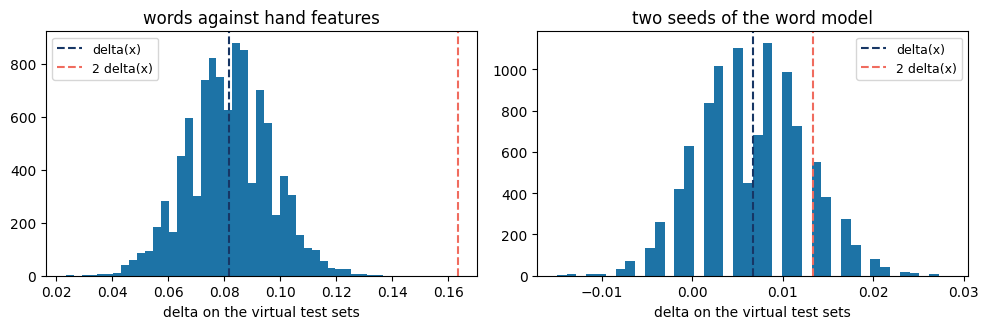

In [13]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, dd, d0, title in [(axes[0], deltas, d, "words against hand features"), (axes[1], deltas2, d2, "two seeds of the word model")]:
    ax.hist(dd, bins=40, color="#1D73A6")
    ax.axvline(d0, color="#173665", ls="--", label="delta(x)"); ax.axvline(2 * d0, color="#F06C5F", ls="--", label="2 delta(x)")
    ax.set_title(title); ax.set_xlabel("delta on the virtual test sets"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

With ten documents even a difference of .20 is not significant: the p-value is about a quarter. On the 600 test reviews the word model beats the hand features on essentially every virtual test set, p ≈ 0, while two runs of the same model with different shuffling differ by a fraction of a point and the p-value is large: that difference is noise, not a better classifier.

## 8. Overfitting and regularization

A model with many features fits the training data too well. To see it, we train the word model on only 150 reviews for many epochs: the training accuracy reaches 100% while the test accuracy stays lower, and the weights grow. An L2 penalty αΣθ<sup>2</sup> (Eq. 4.51) shrinks the weights; too much of it and the model underfits. The right α is chosen with cross-validation, never on the test set; here we show the test accuracy only to see the effect. Then the L1 penalty (Eq. 4.53): it sets most weights exactly to zero, a sparse model with far fewer features. Two details of the code go beyond the lecture: the L2 penalty enters the update through its derivative, 2αθ, which shrinks every weight a little at each step; the L1 penalty is applied with soft thresholding, after each step every weight moves toward 0 by ηα and stops at 0.

In [14]:
small = np.arange(150)
X_small, y_small = B_train[small], y_train[small]
print("L2 regularization, 150 training reviews, 200 epochs:")
print("   alpha   train acc  test acc   largest |w|   sum of w^2")
for l2 in (0, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1):
    W, b, _ = train_softmax(X_small, y_small, eta=0.1, epochs=200, l2=l2)
    print(f"{l2:8}   {accuracy(X_small, y_small, W, b):8.3f}  {accuracy(B_test, y_test, W, b):8.3f}   {np.abs(W).max():10.2f}   {np.sum(W ** 2):10.1f}")

L2 regularization, 150 training reviews, 200 epochs:
   alpha   train acc  test acc   largest |w|   sum of w^2
       0      1.000     0.778         1.66         73.8


  0.0003      1.000     0.783         1.58         66.4
   0.001      0.987     0.788         1.42         53.0
   0.003      0.960     0.793         1.11         31.9


    0.01      0.940     0.798         0.68         12.5
    0.03      0.873     0.757         0.41          4.7


     0.1      0.647     0.570         0.31          1.4


In [15]:
print("L1 regularization, same data:")
print("   alpha   train acc  test acc   non-zero weights (of %d)" % W_b.size)
for l1 in (0, 0.001, 0.003, 0.01, 0.03, 0.1):
    W, b, _ = train_softmax(X_small, y_small, eta=0.1, epochs=200, l1=l1)
    print(f"{l1:8}   {accuracy(X_small, y_small, W, b):8.3f}  {accuracy(B_test, y_test, W, b):8.3f}   {np.sum(W != 0):8d}")

L1 regularization, same data:
   alpha   train acc  test acc   non-zero weights (of 345)
       0      1.000     0.778        345


   0.001      0.987     0.782        320
   0.003      0.947     0.782        289


    0.01      0.907     0.770        212
    0.03      0.607     0.575        143


     0.1      0.493     0.417         43


Without regularization the classifier memorizes the 150 reviews, with large weights on the words that best separate the 150 reviews. A moderate L2 penalty improves the test accuracy and keeps all the weights small; a large one flattens the model. The L1 penalty sets weights exactly to zero: with α = 0.01 it discards more than a third of the 345 weights at a small cost in accuracy, and pushed further it discards too much. With real data and tens of thousands of word features the effect is much larger, since most words carry no information about the class, and L1 leaves a small, sparse model.

## 9. Interpreting the model

Each row of W is the prototype of a class: the words with the largest weights in a row are the strongest evidence for that class, the most negative ones the strongest evidence against it (Section 4.13). Below, the word model of section 4; then the six hand features, whose weights can be compared with the exclamation-mark example of the book: a feature that has a positive weight for two classes and a negative one for the third.

In [16]:
for k, name in enumerate(LABELS):
    order = np.argsort(W_b[k])
    top = ", ".join(f"{vocab[j]} ({W_b[k, j]:.2f})" for j in order[-6:][::-1])
    bottom = ", ".join(f"{vocab[j]} ({W_b[k, j]:.2f})" for j in order[:4])
    print(f"{name:9s} for: {top}\n          against: {bottom}\n")

negative  for: hate (1.49), my (0.80), predictable (0.73), evening (0.66), back (0.66), want (0.66)
          against: love (-1.25), go (-0.79), see (-0.65), wonderful (-0.55)

neutral   for: a (0.52), dubbed (0.45), version (0.45), next (0.44), news (0.38), more (0.38)
          against: is (-0.58), predictable (-0.58), enjoyable (-0.54), dialogue (-0.52)

positive  for: love (1.08), go (0.75), see (0.67), fun (0.66), enjoyable (0.57), recommend (0.56)
          against: hate (-1.40), my (-0.62), boring (-0.58), back (-0.55)



In [17]:
W_raw = W_h / std_h                                                # the learned weights, for the features before standardization
print(f"{'feature':30s} {'negative':>9s} {'neutral':>9s} {'positive':>9s}")
for name, row in zip(FEATURE_NAMES, W_raw.T):
    print(f"{name:30s} {row[0]:9.2f} {row[1]:9.2f} {row[2]:9.2f}")

feature                         negative   neutral  positive
positive lexicon words              0.29     -1.39      1.10
negative lexicon words              1.34     -1.50      0.16
'no' in the review                  0.79     -0.50     -0.30
1st and 2nd person pronouns         0.35     -0.46      0.11
exclamation mark                    0.25     -0.59      0.34
log(length)                        -1.62      2.35     -0.74


The exclamation mark has a positive weight for the positive and the negative class and a negative one for the neutral class, the pattern of the table of the book (3.5, 3.1, -5.3): neutral reviews do not exclaim. The positive lexicon count weighs much more for the positive class than for the negative one, the negative count the reverse, and both are strong evidence against neutral reviews: with the softmax only the differences between the rows of W matter, so two positive weights for the same feature can still separate two classes. The pronouns and the length interact with the other features, as in the previous lecture: a weight cannot be read in isolation, which is why the book insists on controlling for confounds.

## 10. What to do next

- The exercise sheet of this lecture: exercises 1 to 7, 9 and 11 can be checked with the functions of sections 1, 2, 5 and 7 (`softmax`, `ce_loss`, `gradient`, `report`, `paired_bootstrap`); `report` prints 0 where a precision is 0 / 0, undefined.
- Replace accuracy by the macroaveraged F<sub>1</sub> in the bootstrap test of section 7: the test applies to any metric.
- Choose the regularization strength α of section 8 by cross-validation inside the 150 training reviews, as in section 6, and only then look at the test accuracy.
- Add the negation marking of the previous notebook (NOT_ prefixes) to the word features and measure, with the bootstrap test, whether the improvement is significant.
- Write a model card for the word classifier (Section 4.12): training data and their construction, intended use, performance per class.